# Giai đoạn 7 — Chia train / test

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                               07_TachTrainTest                               │
└──────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 06_NiemPhongKhaoSat/train_ttth.csv     —  16.296 dòng × 63 đặc trưng
    • 06_NiemPhongKhaoSat/niem_phong_khaosat.json  —  676 phiếu đã niêm phong
         │
         ▼
  XỬ LÝ
    1. Chia 70 / 15 / 15 — train / val / test
    2. stratify theo NGÀNH để mọi ngành có mặt ở cả ba tập
    3. Niêm phong tập test bằng băm SHA-256
    4. Kiểm tra ba tập không chồng nhau, đủ 39 ngành
         │
         ▼
  ĐẦU RA
    • 07_TachTrainTest/train.csv             —  11.880 dòng
    • 07_TachTrainTest/val.csv               —  2.546 dòng, dùng ở Giai đoạn 9
    • 07_TachTrainTest/test_KHOA.csv         —  KHÔNG mở tới Giai đoạn 10
    • 07_TachTrainTest/niem_phong.json
```

## Chia CHỈ trên phần TTTH

Giai đoạn 6 đã niêm phong toàn bộ 676 phiếu khảo sát. Việc chia ba tập ở đây chỉ diễn
ra trên `train_ttth.csv` — không có phiếu người thật nào tham gia.

```
                     676 phiếu khảo sát  🔒 NIÊM PHONG (Giai đoạn 6)
                             │
                             └──────────────────────────────────┐
train_ttth.csv  16.296 dòng                                     │
        │  stratify theo ma_nganh, seed 42                      │
        ▼                                                        ▼
   ┌──────────┬──────────┬───────────────┐          ┌────────────────────┐
   │ train 70%│  val 15% │ test_KHOA 15% │          │ kiểm định NGƯỜI THẬT│
   └──────────┴──────────┴───────────────┘          └────────────────────┘
     11.407      2.444        2.445                       676 phiếu
        học      chọn siêu     đo nội bộ                   đo ngoại bộ
                 tham số                                   (Giai đoạn 10)
```

Mô hình chỉ nhìn thấy **63 đặc trưng**. Năm cột `ma_nganh`, `ma_nhom`, `nguon`,
`rui_ro_vong_tron`, `sample_weight` nằm ngoài tập đặc trưng, chỉ để ghi chép.
`sample_weight = 1.0` cho cả 16.296 dòng.

## Hai tập kiểm định, hai câu hỏi khác nhau

| Tập | n | Trả lời câu |
|---|--:|---|
| `test_KHOA.csv` | 2.445 | *"mô hình khớp với phân phối nó được học đến đâu?"* |
| `khaosat_NIEMPHONG.csv` | **676** | *"mô hình dự đoán học sinh thật đến đâu?"* ⭐ |

Đây là điểm mạnh của Hướng 2. Hướng 1 chỉ có tập test nội bộ, trong đó phần người thật
lẫn vào và chỉ còn 117 phiếu. Ở đây có hẳn **676 phiếu người thật, chưa mô hình nào
động tới** — gấp gần sáu lần, và không phải trích ra từ đâu cả.

Chênh lệch giữa hai con số chính là mức lạc quan mà dữ liệu sinh bơm vào. Hướng 1 không
đo được chuyện đó một cách sạch sẽ; Hướng 2 đo được.

## Vì sao vẫn 70/15/15

Giữ nguyên tỉ lệ của Hướng 1 để hai hướng so sánh được với nhau. Ở đây lý do "cần thêm
dòng thật trong test" không còn áp dụng — dòng thật đã nằm hết ở tập niêm phong — nhưng
đổi tỉ lệ thì mất khả năng đối chiếu, mà cái đó quý hơn.

## Niêm phong hai lần

`test_KHOA.csv` băm SHA-256 ở đây, `khaosat_NIEMPHONG.csv` đã băm ở Giai đoạn 6. Giai
đoạn 10 kiểm lại **cả hai** mã băm trước khi mở. Giai đoạn 8 và 9 không được mở file
nào trong hai file đó — chúng dùng `val.csv`.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_NiemPhongKhaoSat",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    ⚠️ HƯỚNG 2 — khác Hướng 1 ở chỗ căn bản: 676 phiếu khảo sát KHÔNG bao giờ
    vào tập huấn luyện. Giai đoạn 6 niêm phong toàn bộ chúng làm tập kiểm định
    người thật độc lập; chia train/val/test chỉ diễn ra trên phần TTTH.

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu — chỉ để BỘ SINH học
                                     phân phối, không phải để XGBoost học
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở CẢ HAI tập kiểm định ĐÚNG MỘT LẦN:
                                     test TTTH và 676 phiếu khảo sát niêm phong

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")
        # Tập kiểm định NGƯỜI THẬT — niêm phong từ Giai đoạn 6, mở cùng lúc.
        d["khaosat_niemphong"] = pd.read_csv(thu_muc(6) / "khaosat_NIEMPHONG.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

import hashlib
from sklearn.model_selection import train_test_split

OUT = thu_muc(7)
P_VAL = 0.15
P_TEST = 0.15

D = nap(co_ttth=False)
tf = pd.read_csv(thu_muc(6) / "train_ttth.csv")
NPK = json.loads((thu_muc(6) / "niem_phong_khaosat.json").read_text(encoding="utf-8"))
QL = ["ma_nganh", "ma_nhom", "nguon", "rui_ro_vong_tron", "sample_weight"]
COT_DT = [c for c in tf.columns if c not in QL]
y_all = tf.ma_nganh.values

print(f"Bảng train final: {len(tf):,} dòng")
print(f"   mô hình THẤY      : {len(COT_DT)} đặc trưng")
print(f"   chỉ để ghi chép   : {QL}")
print(f"   sample_weight     : {sorted(tf.sample_weight.unique())}  → mọi dòng ngang nhau")
print(f"\n   ⚠️ KHÔNG có phiếu khảo sát nào ở đây — {NPK['n_dong']} phiếu đã niêm phong")
print(f"   rò rỉ vòng tròn   : {int(tf.rui_ro_vong_tron.sum()):,} dòng"
      f" ({100*tf.rui_ro_vong_tron.mean():.1f}%) thuộc {len(NPK['nganh_vong_tron'])} ngành")
print(f"   ngành             : {tf.ma_nganh.nunique()}/39"
      f" · ít nhất {tf.ma_nganh.value_counts().min():,} dòng")
print(f"\nChia {1-P_VAL-P_TEST:.0%} / {P_VAL:.0%} / {P_TEST:.0%}  (train / val / test)")

Bảng train final: 16,296 dòng
   mô hình THẤY      : 63 đặc trưng
   chỉ để ghi chép   : ['ma_nganh', 'ma_nhom', 'nguon', 'rui_ro_vong_tron', 'sample_weight']
   sample_weight     : [1.0]  → mọi dòng ngang nhau

   ⚠️ KHÔNG có phiếu khảo sát nào ở đây — 676 phiếu đã niêm phong
   rò rỉ vòng tròn   : 600 dòng (3.7%) thuộc 5 ngành
   ngành             : 39/39 · ít nhất 18 dòng

Chia 70% / 15% / 15%  (train / val / test)


## 1. Chia ba tập

In [2]:
# Chia hai bước: tách test+val ra trước, rồi chia đôi. stratify theo NGÀNH ở cả
# hai bước để mọi ngành có mặt ở cả ba tập — ngành ít nhất chỉ 36 dòng, chia
# ngẫu nhiên không stratify thì có ngành biến mất khỏi test.
i_tr, i_tmp = train_test_split(
    np.arange(len(tf)), test_size=P_VAL + P_TEST, stratify=y_all, random_state=SEED)
i_va, i_te = train_test_split(
    i_tmp, test_size=P_TEST / (P_VAL + P_TEST), stratify=y_all[i_tmp],
    random_state=SEED)

train = tf.iloc[i_tr].reset_index(drop=True)
val = tf.iloc[i_va].reset_index(drop=True)
test = tf.iloc[i_te].reset_index(drop=True)

train.to_csv(OUT / "train.csv", index=False)
val.to_csv(OUT / "val.csv", index=False)
test.to_csv(OUT / "test_KHOA.csv", index=False)

print(f"{'tập':<8}{'dòng':>9}{'ngành':>8}{'vòng tròn':>12}")
print("-" * 40)
for ten, d in [("train", train), ("val", val), ("test", test)]:
    print(f"{ten:<8}{len(d):>9,}{d.ma_nganh.nunique():>8}"
          f"{int(d.rui_ro_vong_tron.sum()):>12,}")

assert len(set(i_tr) & set(i_va)) == 0, "train và val chồng nhau"
assert len(set(i_tr) & set(i_te)) == 0, "train và test chồng nhau"
assert len(set(i_va) & set(i_te)) == 0, "val và test chồng nhau"
assert len(i_tr) + len(i_va) + len(i_te) == len(tf), "mất dòng"
for ten, d in [("train", train), ("val", val), ("test", test)]:
    assert d.ma_nganh.nunique() == 39, f"{ten} thiếu ngành"
assert "is_that" not in tf.columns, "Hướng 2 không có cột is_that — khảo sát đã niêm phong"
print("\n✓ ba tập rời nhau · đủ 39 ngành")
print("✓ không phiếu khảo sát nào lọt vào ba tập này")

tập          dòng   ngành   vòng tròn
----------------------------------------
train      11,407      39         420
val         2,444      39          90
test        2,445      39          90

✓ ba tập rời nhau · đủ 39 ngành
✓ không phiếu khảo sát nào lọt vào ba tập này


## 2. Niêm phong tập test

In [3]:
bam = hashlib.sha256((OUT / "test_KHOA.csv").read_bytes()).hexdigest()
# Khoảng tin cậy 95% cho một tỉ lệ ước lượng quanh 0,80
sai_so = 1.96 * np.sqrt(.8 * .2 / len(test)) * 100
sai_so_ks = 1.96 * np.sqrt(.8 * .2 / NPK["n_dong"]) * 100

(OUT / "niem_phong.json").write_text(json.dumps({
    "file": "test_KHOA.csv", "bam_sha256": bam,
    "n_dong": int(len(test)),
    "p_train": 1 - P_VAL - P_TEST, "p_val": P_VAL, "p_test": P_TEST, "seed": SEED,
    "sai_so_95": round(float(sai_so), 1),
    "sai_so_95_khaosat_niemphong": round(float(sai_so_ks), 1),
    "ghi_chu": "Giai đoạn 8 và 9 KHÔNG được mở — dùng val.csv. "
               "Giai đoạn 10 kiểm băm trước khi mở.",
}, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"🔒 test_KHOA.csv       {bam[:48]}…")
print(f"🔒 khaosat_NIEMPHONG   {NPK['bam_sha256'][:48]}…  (băm ở Giai đoạn 6)")
print(f"\nHAI tập kiểm định, Giai đoạn 10 mở cả hai:")
print(f"   test_KHOA.csv          {len(test):>6,} dòng  ±{sai_so:.1f} điểm (95%)")
print(f"   khaosat_NIEMPHONG.csv  {NPK['n_dong']:>6,} phiếu ±{sai_so_ks:.1f} điểm (95%)"
      f"   ← người thật, chưa mô hình nào thấy")
print(f"\nChênh lệch giữa hai con số chính là mức lạc quan do dữ liệu sinh bơm vào.")

🔒 test_KHOA.csv       fca56fce42a3a9a306af4c5ecf74b5b4a11714c01bf83524…
🔒 khaosat_NIEMPHONG   99fb31be34977fccbac79b68f0b18abffd613204b016fdbc…  (băm ở Giai đoạn 6)

HAI tập kiểm định, Giai đoạn 10 mở cả hai:
   test_KHOA.csv           2,445 dòng  ±1.6 điểm (95%)
   khaosat_NIEMPHONG.csv     676 phiếu ±3.0 điểm (95%)   ← người thật, chưa mô hình nào thấy

Chênh lệch giữa hai con số chính là mức lạc quan do dữ liệu sinh bơm vào.


   💾 hinh_7_1_ba_tap.png


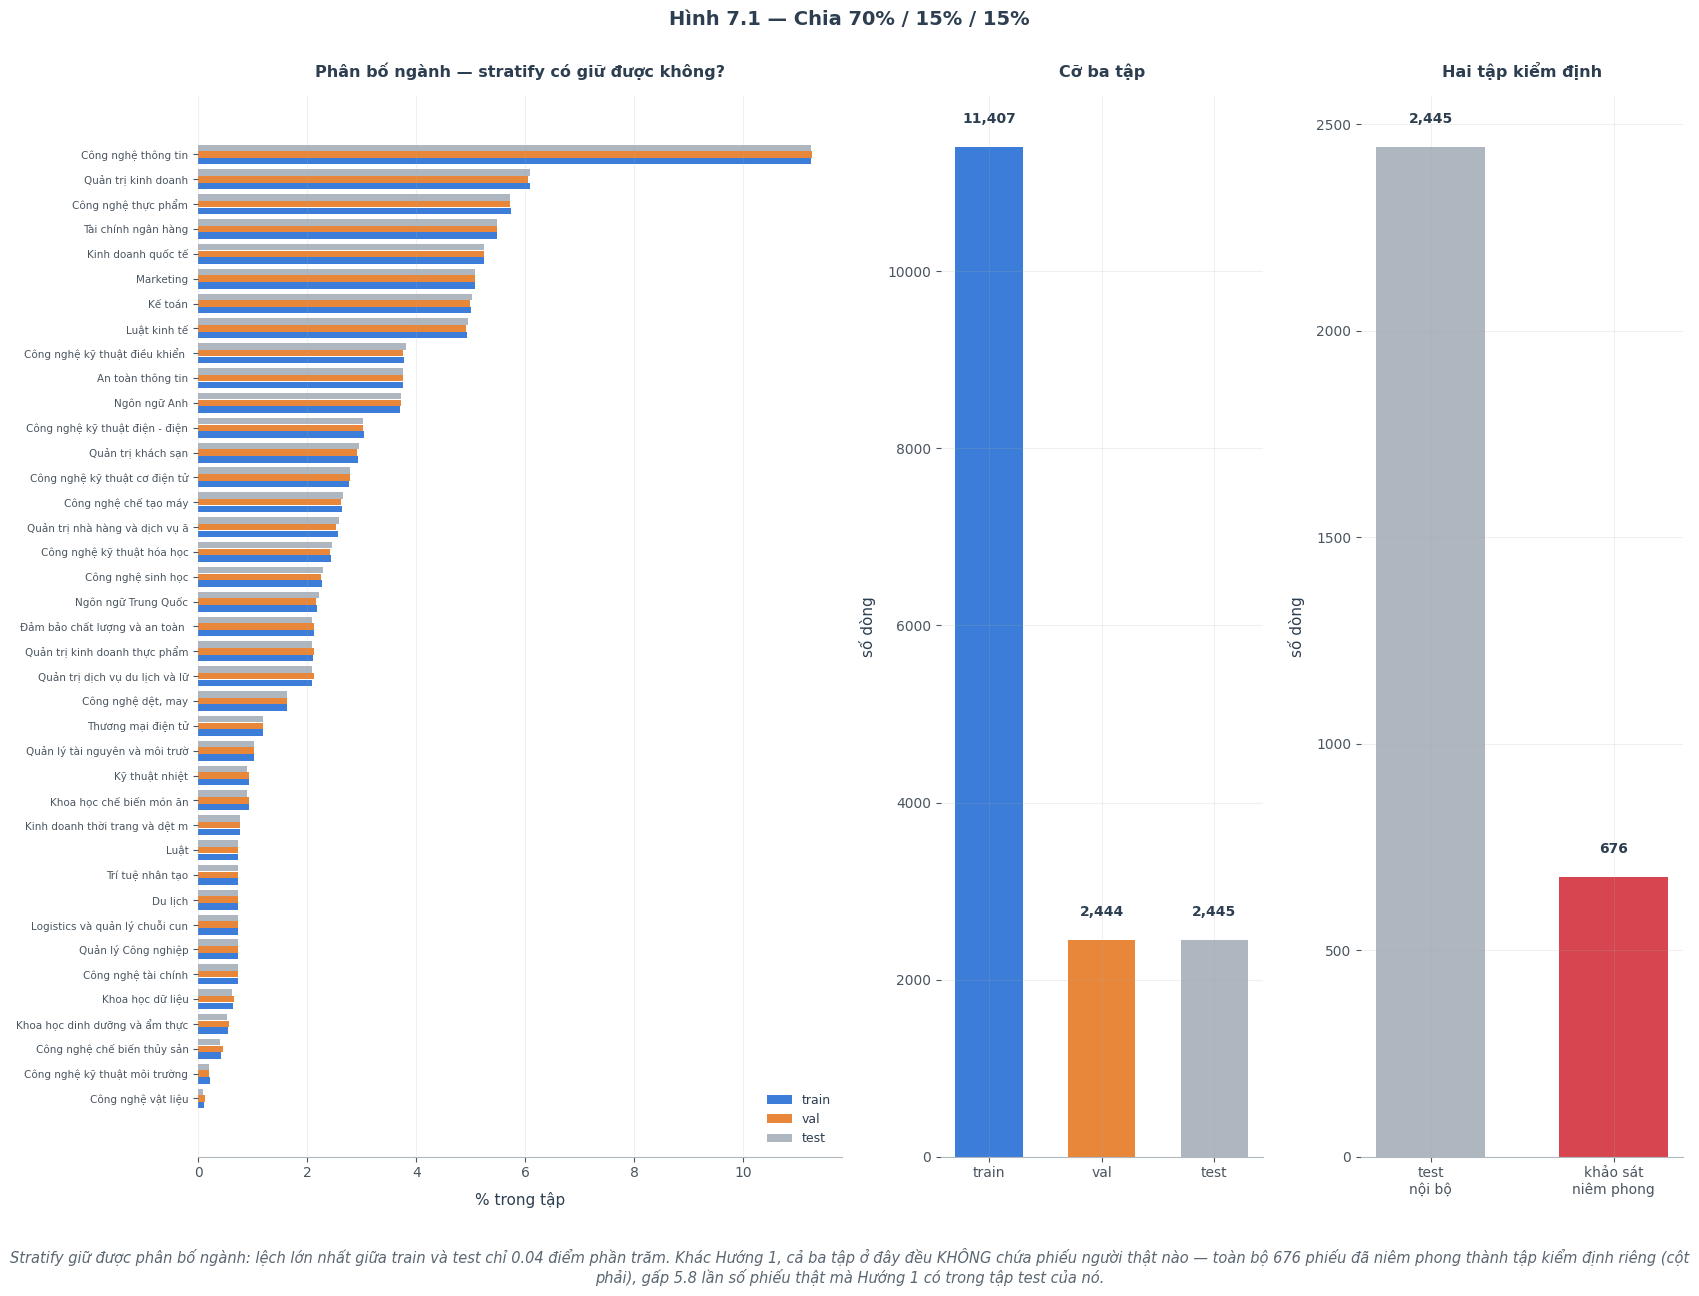

In [4]:
# ═══════════ HÌNH 7.1 — Ba tập sau khi chia ═══════════
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(17, cao_theo_dong(39)),
                                 gridspec_kw={"width_ratios": [1.6, .8, .8]})
pt = pd.DataFrame({
    "train": train.ma_nganh.value_counts(normalize=True),
    "val": val.ma_nganh.value_counts(normalize=True),
    "test": test.ma_nganh.value_counts(normalize=True)}).fillna(0).sort_values("train")
pt["ten"] = [D["ma_to_ten"][m][:30] for m in pt.index]
yy = np.arange(len(pt))
for j, (c, mau_) in enumerate([("train", C_XANH), ("val", C_CAM), ("test", C_XAM)]):
    a1.barh(yy + (j - 1) * .27, pt[c] * 100, .26, color=mau_, label=c)
a1.set_yticks(yy); a1.set_yticklabels(pt.ten, fontsize=7.5)
a1.set_xlabel("% trong tập"); a1.legend(fontsize=9); a1.grid(axis="y", alpha=0)
a1.set_title("Phân bố ngành — stratify có giữ được không?", fontsize=11.5)

ten3 = ["train", "val", "test"]
sl3 = [len(train), len(val), len(test)]
a2.bar(ten3, sl3, color=[C_XANH, C_CAM, C_XAM], width=.6)
nhan_doc(a2, fmt="{:,.0f}")
a2.set_ylabel("số dòng"); a2.set_title("Cỡ ba tập", fontsize=11.5)

a3.bar(["test\nnội bộ", "khảo sát\nniêm phong"], [len(test), NPK["n_dong"]],
       color=[C_XAM, C_THAT], width=.6)
nhan_doc(a3, fmt="{:,.0f}")
a3.set_ylabel("số dòng")
a3.set_title("Hai tập kiểm định", fontsize=11.5)

fig.suptitle(f"Hình 7.1 — Chia {1-P_VAL-P_TEST:.0%} / {P_VAL:.0%} / {P_TEST:.0%}",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
lech = float((pt.train - pt.test).abs().max() * 100)
luu(fig, OUT, "hinh_7_1_ba_tap.png",
    f"Stratify giữ được phân bố ngành: lệch lớn nhất giữa train và test chỉ {lech:.2f} "
    f"điểm phần trăm. Khác Hướng 1, cả ba tập ở đây đều KHÔNG chứa phiếu người thật nào "
    f"— toàn bộ {NPK['n_dong']} phiếu đã niêm phong thành tập kiểm định riêng (cột phải), "
    f"gấp {NPK['n_dong']/117:.1f} lần số phiếu thật mà Hướng 1 có trong tập test của nó.")
plt.show()

In [5]:
tom_tat("GIAI ĐOẠN 7 — CHIA TRAIN / VAL / TEST", [
    f"Nguồn                  train_ttth.csv  {len(tf):,} dòng",
    f"Mô hình thấy           {len(COT_DT)} đặc trưng"
    f"  (5 cột quản lý nằm ngoài)",
    "Trọng số               1.0 cho MỌI dòng",
    "",
    f"train                  {len(train):>7,} dòng",
    f"val                    {len(val):>7,} dòng",
    f"test  (niêm phong)     {len(test):>7,} dòng",
    "",
    f"🔒 khaosat_NIEMPHONG   {NPK['n_dong']:>7,} phiếu NGƯỜI THẬT",
    f"   niêm phong ở Giai đoạn 6, mô hình chưa từng thấy",
    "",
    f"Stratify               theo ngành · seed {SEED}",
    f"Băm niêm phong         {bam[:16]}…",
    "",
    "⚠️  Giai đoạn 8 và 9 dùng val.csv, KHÔNG mở file niêm phong nào",
    f"⚠️  Giai đoạn 10 mở CẢ HAI: test (±{sai_so:.1f}đ) và khảo sát (±{sai_so_ks:.1f}đ)",
])
print(f"\n✅ train.csv · val.csv · test_KHOA.csv · niem_phong.json · 1 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 7 — CHIA TRAIN / VAL / TEST                    ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Nguồn                  train_ttth.csv  16,296 dòng                         ║
║ Mô hình thấy           63 đặc trưng  (5 cột quản lý nằm ngoài)             ║
║ Trọng số               1.0 cho MỌI dòng                                    ║
║                                                                            ║
║ train                   11,407 dòng                                        ║
║ val                      2,444 dòng                                        ║
║ test  (niêm phong)       2,445 dòng                                        ║
║                                                                            ║
║ 🔒 khaosat_NIEMPHONG       676 phiếu NGƯỜI THẬT                             ║
║    niêm phong ở Giai đoạn 6, mô hình chưa từng thấ